**6.10. Calculus - Hands-On in Python**

In [1]:
# Install required packages
%pip install -q numpy matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [57]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

**1. A SImple Line: y = 2x + 1**

In [58]:
# define line function
def line_func(x):
    return 2 * x + 1

In [59]:
x = np.linspace(-3, 3, 100)
y = line_func(x)

In [60]:
print(x[:5])
print(y[:5])

[-3.         -2.93939394 -2.87878788 -2.81818182 -2.75757576]
[-5.         -4.87878788 -4.75757576 -4.63636364 -4.51515152]


slope = rise / run

(or)

slope = dy/dx

(or)

slope = change in y / change in x

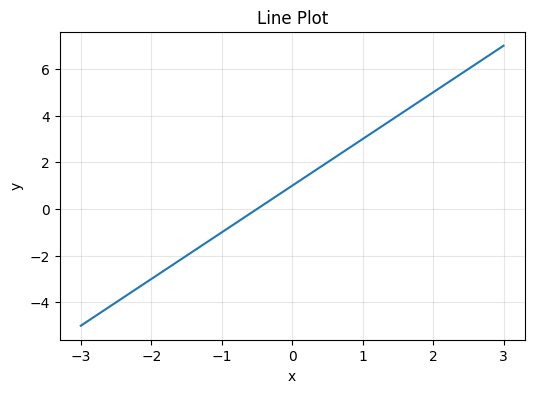

--------------------------------------------------
Line Example
Point 1: (-2,-3)
Point 2: (1,3)
Rise: 6
Run: 3
Slope (rise / run): 2.0
--------------------------------------------------


In [65]:
# given x & y values, find the slope of the line

plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.title("Line Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()


# choose two points on the line
x1, x2 = -2, 1
y1, y2 = line_func(x1), line_func(x2)

rise = y2 - y1
run = x2 - x1

slope = rise / run

print("-"*50)
print("Line Example")
print("Point 1:", f"({x1},{y1})")
print("Point 2:", f"({x2},{y2})")
print("Rise:", rise)
print("Run:", run)
print("Slope (rise / run):", slope)
print("-"*50)

In [64]:
# x1, x2 = -2, 1
# y1, y2 = line_func(x1), line_func(x2)

# print(f"({x1},{y1})")
# print(f"({x2},{y2})")

**2. Curve: y=x^2**

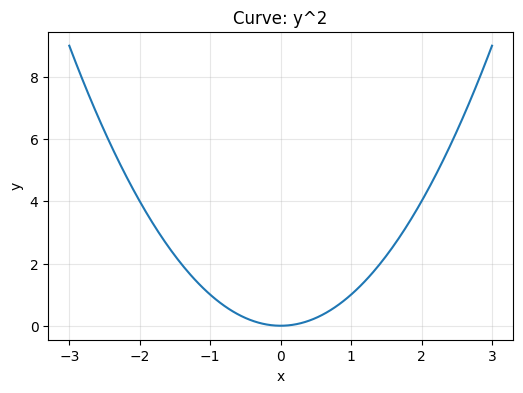

In [66]:
def curve(x):
    return x**2

x_vals = np.linspace(-3, 3, 200)
y_vals = curve(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Curve: y^2")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

**3. Estimating slope with a small change in x**

Idea:
If we move x a tiny bit and see how much y changes,
that change in y divided by change in x gives an approximate slope.

slope = dy / dx

- dy = change in y
- dx = change in x

In [83]:
def slope_estimate(func, x1, h=0.00001):
    x2 = x1 + h
    y1 = curve(x1)
    y2 = func(x2)
    dy = y2 - y1
    dx = h
    slope = dy / dx
    return slope


In [84]:
points = [-2, 0, 2]

print("Slope estimates for y=x^2 using small change in x")

for p in points:
    s = slope_estimate(curve, p)
    print(f"x = {p:.1f} -> estimated slope = {s:.2f}")

Slope estimates for y=x^2 using small change in x
x = -2.0 -> estimated slope = -4.00
x = 0.0 -> estimated slope = 0.00
x = 2.0 -> estimated slope = 4.00


**Simple explanation of dloss and weight update**

Your model predicts values using:

**y_pred = w * x**

We want these predictions to match the real values, so we use Mean Squared Error:

**L = average of (y_pred - y_true) squared**

To reduce this loss, we take the derivative.
The derivative tells us how the loss changes when w changes.

For this model, the derivative of the loss with respect to w becomes:

**dL/dw = average of [2 * x * (w*x - y)]**

This is exactly what your dloss function calculates.

During gradient descent, the weight is updated using:

**w = w - learning_rate * (dL/dw)**

If dL/dw is positive, increasing w increases loss, so we reduce w.
If dL/dw is negative, decreasing w increases loss, so we increase w.

This slowly moves w toward the value that gives the smallest loss.

In [2]:
import numpy as np

# sample dataset
x = np.array([1, 2, 3])
y_true = np.array([2, 4, 6])


# f(x) = w * x
# y = w * x

# starting guess of w
w = 1.0

# learning rate
lr = 0.01

def loss(w):
    y_pred = w * x
    return np.mean((y_pred - y_true) ** 2)


# dloss -> dL/dw
def dloss(w):
    y_pred = w * x
    return np.mean(2 * x * (y_pred - y_true))

print("Start w:", w, "loss:", loss(w))

for step in range(30):
    slope = dloss(w)
    w = w - lr * slope
    print("Step", step + 1, "w:", round(w, 3), "loss:", round(loss(w), 3))

Start w: 1.0 loss: 4.666666666666667
Step 1 w: 1.093 loss: 3.836
Step 2 w: 1.178 loss: 3.154
Step 3 w: 1.255 loss: 2.592
Step 4 w: 1.324 loss: 2.131
Step 5 w: 1.387 loss: 1.752
Step 6 w: 1.444 loss: 1.44
Step 7 w: 1.496 loss: 1.184
Step 8 w: 1.543 loss: 0.973
Step 9 w: 1.586 loss: 0.8
Step 10 w: 1.625 loss: 0.658
Step 11 w: 1.66 loss: 0.541
Step 12 w: 1.691 loss: 0.444
Step 13 w: 1.72 loss: 0.365
Step 14 w: 1.746 loss: 0.3
Step 15 w: 1.77 loss: 0.247
Step 16 w: 1.791 loss: 0.203
Step 17 w: 1.811 loss: 0.167
Step 18 w: 1.829 loss: 0.137
Step 19 w: 1.845 loss: 0.113
Step 20 w: 1.859 loss: 0.093
Step 21 w: 1.872 loss: 0.076
Step 22 w: 1.884 loss: 0.063
Step 23 w: 1.895 loss: 0.051
Step 24 w: 1.905 loss: 0.042
Step 25 w: 1.914 loss: 0.035
Step 26 w: 1.922 loss: 0.029
Step 27 w: 1.929 loss: 0.024
Step 28 w: 1.936 loss: 0.019
Step 29 w: 1.942 loss: 0.016
Step 30 w: 1.947 loss: 0.013
